# Evaluate Causal3DIdent checkpoints

This notebook automatically discovers the project root, extracted Causal3DIdent data, and completed Causal3DIdent checkpoints. It fits probes on one part of the official test split and reports scores on a disjoint part. Both equal-dimensional models and overcomplete controls are evaluated; only the former carry the nuisance-removal guarantee.

In [ ]:
from __future__ import annotations
from _plotting_style import CAT_COLORS, SEQ_COLORS

import argparse
import json
import os
import re
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from _plotting_style import CAT_COLORS, SEQ_COLORS
import numpy as np
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'implicit_nuisance').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'implicit_nuisance').is_dir():
    raise RuntimeError('Could not locate the implicit_nuisance project root')
sys.path.insert(0, str(PROJECT_ROOT))

from eval.causal3dident_eval import (
    _collect_representations,
    _extract_from_checkpoint,
    _load_config,
    _load_local_model,
)
from implicit_nuisance.data.causal3dident import Causal3DIdent
from implicit_nuisance.utils.causal3dident_eval import (
    CAUSAL3DIDENT_FACTOR_NAMES,
    DEFAULT_SIGNAL_INDICES,
    evaluate_representations,
)

print('Project root:', PROJECT_ROOT)
print('Inference device:', 'cuda' if torch.cuda.is_available() else 'cpu')

## Evaluation settings

The defaults evaluate the latest completed run for every `(model name, seed)` pair. Set `RUN_NAME_FILTER` to a substring such as `logdet_3` to evaluate fewer runs.

In [36]:
RUN_NAME_FILTER = None       # e.g. 'causal3dident_logdet_3'
MAX_RUNS = None              # e.g. 1 for a quick smoke test
MAX_PROBE_TRAIN = 2_000
MAX_PROBE_TEST = 2_000
BATCH_SIZE = 64
NUM_WORKERS = 4
NUM_IMAGE_PAIRS = 8
MLP_HIDDEN_LAYER_SIZES = (256, 256, 256)
MLP_MAX_ITER = 500
RANDOM_SEED = 3
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

## Automatically discover data and checkpoints

In [ ]:
def is_causal3dident_root(path):
    path = Path(path).expanduser()
    return all(
        (path / split / 'raw_latents_0.npy').is_file()
        for split in ('trainset', 'testset')
    )


def checkpoint_epoch(path):
    match = re.search(r'ep=(\d+)', path.name)
    return int(match.group(1)) if match else -1


def discover_runs(project_root):
    candidates = []
    for config_path in (project_root / 'trained_models').glob('**/args.json'):
        try:
            config = json.loads(config_path.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        if config.get('data', {}).get('dataset') != 'causal3dident':
            continue
        name = str(config.get('name', config_path.parent.parent.name))
        if RUN_NAME_FILTER and RUN_NAME_FILTER not in name:
            continue
        checkpoints = list(config_path.parent.glob('*.ckpt'))
        if not checkpoints:
            continue
        checkpoint = max(checkpoints, key=lambda path: (checkpoint_epoch(path), path.stat().st_mtime))
        candidates.append({
            'name': name,
            'seed': int(config.get('seed', 0)),
            'state_dim': int(config['method_kwargs']['state_dim']),
            'loss': config['method_kwargs']['loss_type'],
            'config': config_path,
            'checkpoint': checkpoint,
            'epoch': checkpoint_epoch(checkpoint),
            'mtime': checkpoint.stat().st_mtime,
            'configured_data_root': config.get('data', {}).get('settings', {}).get('root'),
        })

    latest = {}
    for run in candidates:
        key = (run['name'], run['seed'])
        score = (run['epoch'], run['mtime'])
        if key not in latest or score > (latest[key]['epoch'], latest[key]['mtime']):
            latest[key] = run
    runs = sorted(latest.values(), key=lambda run: (run['name'], run['seed']))
    return runs[:MAX_RUNS] if MAX_RUNS is not None else runs


runs = discover_runs(PROJECT_ROOT)
if not runs:
    raise FileNotFoundError('No completed Causal3DIdent checkpoints were found under trained_models/')

data_candidates = []
if os.environ.get('CAUSAL3DIDENT_ROOT'):
    data_candidates.append(Path(os.environ['CAUSAL3DIDENT_ROOT']))
for run in runs:
    configured = run['configured_data_root']
    if configured:
        configured = Path(configured).expanduser()
        data_candidates.append(configured if configured.is_absolute() else PROJECT_ROOT / configured)
data_candidates.extend([
    PROJECT_ROOT / 'datasets' / 'Causal3DIdent',
    PROJECT_ROOT / 'datasets' / 'causal3dident',
    PROJECT_ROOT.parent / 'datasets' / 'Causal3DIdent',
])
DATA_ROOT = next((path.resolve() for path in data_candidates if is_causal3dident_root(path)), None)
if DATA_ROOT is None:
    checked = '\n'.join(f'  - {path}' for path in dict.fromkeys(data_candidates))
    raise FileNotFoundError(
        'Could not locate Causal3DIdent. Set CAUSAL3DIDENT_ROOT or place it under datasets/. '
        f'Checked:\n{checked}'
    )

print('Dataset root:', DATA_ROOT)
display([{key: value for key, value in run.items() if key not in {'mtime', 'configured_data_root'}} for run in runs])

## Inspect paired samples

Only the configured signal factors follow the transition. For each signal value, the dataset maps $s_1 \in [-1, 1]$ to normal-score coordinates $u_1 = \Phi^{-1}((s_1 + 1) / 2)$ and samples

$$u_2^* = \rho u_1 + \epsilon, \qquad \epsilon \sim \mathcal{N}(0, \sigma^2 I).$$

Image 2 is an actual dataset rendering selected uniformly from the $k$ nearest neighbors of $u_2^*$, so its realized signal is close to—but generally not exactly—the Gaussian target. Its non-signal factors are inherited from that selected row rather than copied from image 1. In the environment-signal scenario the next object class is sampled uniformly before lookup; in the object-signal scenario joint kNN lookup samples the environment and class together conditional on the object factors.

/tmp/ipykernel_2741527/2691196051.py:50: UserWarning: The figure layout has changed to tight
  fig.tight_layout(rect=(0, 0, 1, 0.97))


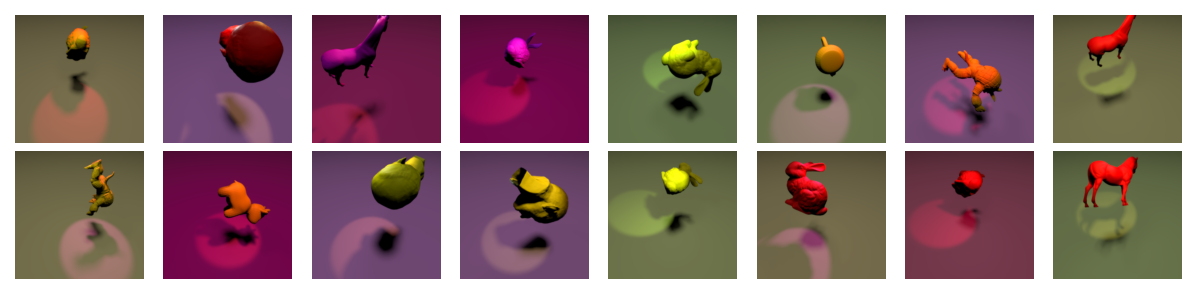

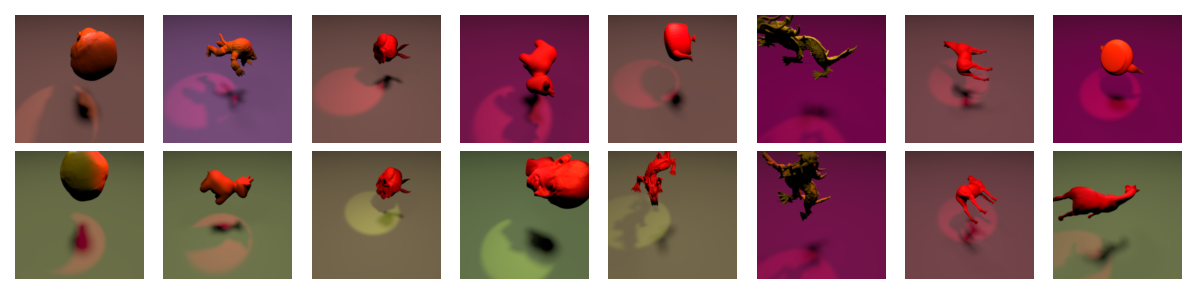

In [38]:
SCENARIOS = {
    (6, 8, 9): {
        'title': 'Environment signal',
        'signal': (6, 8, 9),
        'nuisance': (0, 1, 2, 3, 4, 5, 7),
    },
    (0, 1, 2, 3, 4, 5, 7): {
        'title': 'Object signal',
        'signal': (0, 1, 2, 3, 4, 5, 7),
        'nuisance': (6, 8, 9),
    },
}


def run_signal_indices(run):
    config = json.loads(run['config'].read_text())
    return tuple(config['data']['settings']['signal_indices'])


def denormalize_image(image, dataset):
    image = image * dataset._normalization_std + dataset._normalization_mean
    return image.permute(1, 2, 0).numpy().clip(0, 1)


def plot_sample_pairs(signal_indices, scenario, rng):
    matching_run = next(
        (run for run in runs if run_signal_indices(run) == signal_indices),
        None,
    )
    if matching_run is None:
        print(f"{scenario['title']}: no matching run configuration found")
        return

    cfg = _load_config(matching_run['config'])
    cfg.data.settings.root = str(DATA_ROOT)
    cfg.data.settings.stochastic_transitions = False
    dataset = Causal3DIdent(cfg, split='test')
    num_pairs = min(NUM_IMAGE_PAIRS, len(dataset))
    pair_indices = rng.choice(len(dataset), size=num_pairs, replace=False)

    fig, axes = plt.subplots(2, num_pairs, figsize=(1 * num_pairs,2), squeeze=False)
    signal_names = [CAUSAL3DIDENT_FACTOR_NAMES[index] for index in signal_indices]
    # fig.suptitle(f"{scenario['title']}\nCorrelated factors: {', '.join(signal_names)}")
    for ind, pair_index in enumerate(pair_indices):
        images, labels = dataset[int(pair_index)]
        axes[0,ind].imshow(denormalize_image(images[0], dataset))
        axes[0,ind].set_axis_off()
        axes[1,ind].imshow(denormalize_image(images[1], dataset))
        axes[1,ind].set_axis_off()
    fig.tight_layout(rect=(0, 0, 1, 0.97))
    plt.savefig(f"plots/c3d_{scenario['title']}.pdf")


pair_rng = np.random.default_rng(RANDOM_SEED)
for signal_indices, scenario in SCENARIOS.items():
    plot_sample_pairs(signal_indices, scenario, pair_rng)

## Extract representations and run held-out probes

This is the expensive cell. Linear probes are fitted on one held-out partition and scored on a disjoint partition.

In [28]:
results = []
failures = []
for run_number, run in enumerate(runs, 1):
    print(f"[{run_number}/{len(runs)}] {run['name']} seed={run['seed']} epoch={run['epoch']}")
    args = argparse.Namespace(
        config=run['config'],
        data_root=DATA_ROOT,
        device=DEVICE,
        checkpoint=run['checkpoint'],
        representation_key='inferences',
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        max_train_samples=MAX_PROBE_TRAIN,
        max_test_samples=MAX_PROBE_TEST,
        seed=RANDOM_SEED,
    )
    try:
        arrays, gaussian_metrics = _extract_from_checkpoint(args)
        signal_indices = tuple(gaussian_metrics['metadata']['signal_indices'])
        metrics = evaluate_representations(
            *arrays,
            signal_indices=signal_indices,
            signal_transform='normal_score',
            factor_names=CAUSAL3DIDENT_FACTOR_NAMES,
        )
        metrics['gaussian_conditional'] = gaussian_metrics
        results.append({**run, 'metrics': metrics})
    except Exception as error:
        failures.append({'name': run['name'], 'seed': run['seed'], 'error': repr(error)})
        print('  FAILED:', repr(error))
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

if failures:
    print('Failures:')
    display(failures)
if not results:
    raise RuntimeError('No checkpoint was evaluated successfully')
print(f'Successfully evaluated {len(results)} of {len(runs)} runs.')

[1/30] causal3dident_environment_semantic_kde_10 seed=1 epoch=24
[2/30] causal3dident_environment_semantic_kde_10 seed=2 epoch=24
[3/30] causal3dident_environment_semantic_kde_10 seed=3 epoch=24
[4/30] causal3dident_environment_semantic_kde_10 seed=4 epoch=24
[5/30] causal3dident_environment_semantic_kde_10 seed=5 epoch=24
[6/30] causal3dident_environment_semantic_knn_10 seed=1 epoch=24
[7/30] causal3dident_environment_semantic_knn_10 seed=2 epoch=24
[8/30] causal3dident_environment_semantic_knn_10 seed=3 epoch=24
[9/30] causal3dident_environment_semantic_knn_10 seed=4 epoch=24
[10/30] causal3dident_environment_semantic_knn_10 seed=5 epoch=24
[11/30] causal3dident_environment_semantic_logdet_10 seed=1 epoch=24
[12/30] causal3dident_environment_semantic_logdet_10 seed=2 epoch=24
[13/30] causal3dident_environment_semantic_logdet_10 seed=3 epoch=24
[14/30] causal3dident_environment_semantic_logdet_10 seed=4 epoch=24
[15/30] causal3dident_environment_semantic_logdet_10 seed=5 epoch=24
[16/

## Inspect metrics and factor recovery

The first figure treats spotlight position/hue and background hue as signal. The second uses the object position, rotation, and hue as signal. Each bar is the mean across training seeds and its error bar is the sample standard deviation. The figures separate signal from continuous nuisance factors; object class is also nuisance, but is reported by classification accuracy rather than $R^2$.

[{'model': 'causal3dident_environment_semantic_kde_10',
  'seeds': [1, 2, 3, 4, 5],
  'n_seeds': 5,
  'd_z': 10,
  'equal_dimensional': False,
  'signal_affine_r2_mean': np.float64(0.9847600758518201),
  'signal_affine_r2_std': np.float64(0.00048449213559803757),
  'conditional_nuisance_delta_r2_mean': np.float64(0.22569729687031148),
  'conditional_nuisance_delta_r2_std': np.float64(0.019554122131618865),
  'class_accuracy_mean': np.float64(0.47620000000000007),
  'class_accuracy_std': np.float64(0.04918663436341217),
  'gaussian_nll_per_dim_mean': np.float64(0.3252797380968155),
  'gaussian_nll_per_dim_std': np.float64(0.09477568019718778)},
 {'model': 'causal3dident_environment_semantic_knn_10',
  'seeds': [1, 2, 3, 4, 5],
  'n_seeds': 5,
  'd_z': 10,
  'equal_dimensional': False,
  'signal_affine_r2_mean': np.float64(0.9801558850061431),
  'signal_affine_r2_std': np.float64(0.0006061243576435935),
  'conditional_nuisance_delta_r2_mean': np.float64(0.16382192749883942),
  'condition

/tmp/ipykernel_2741527/4214246526.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


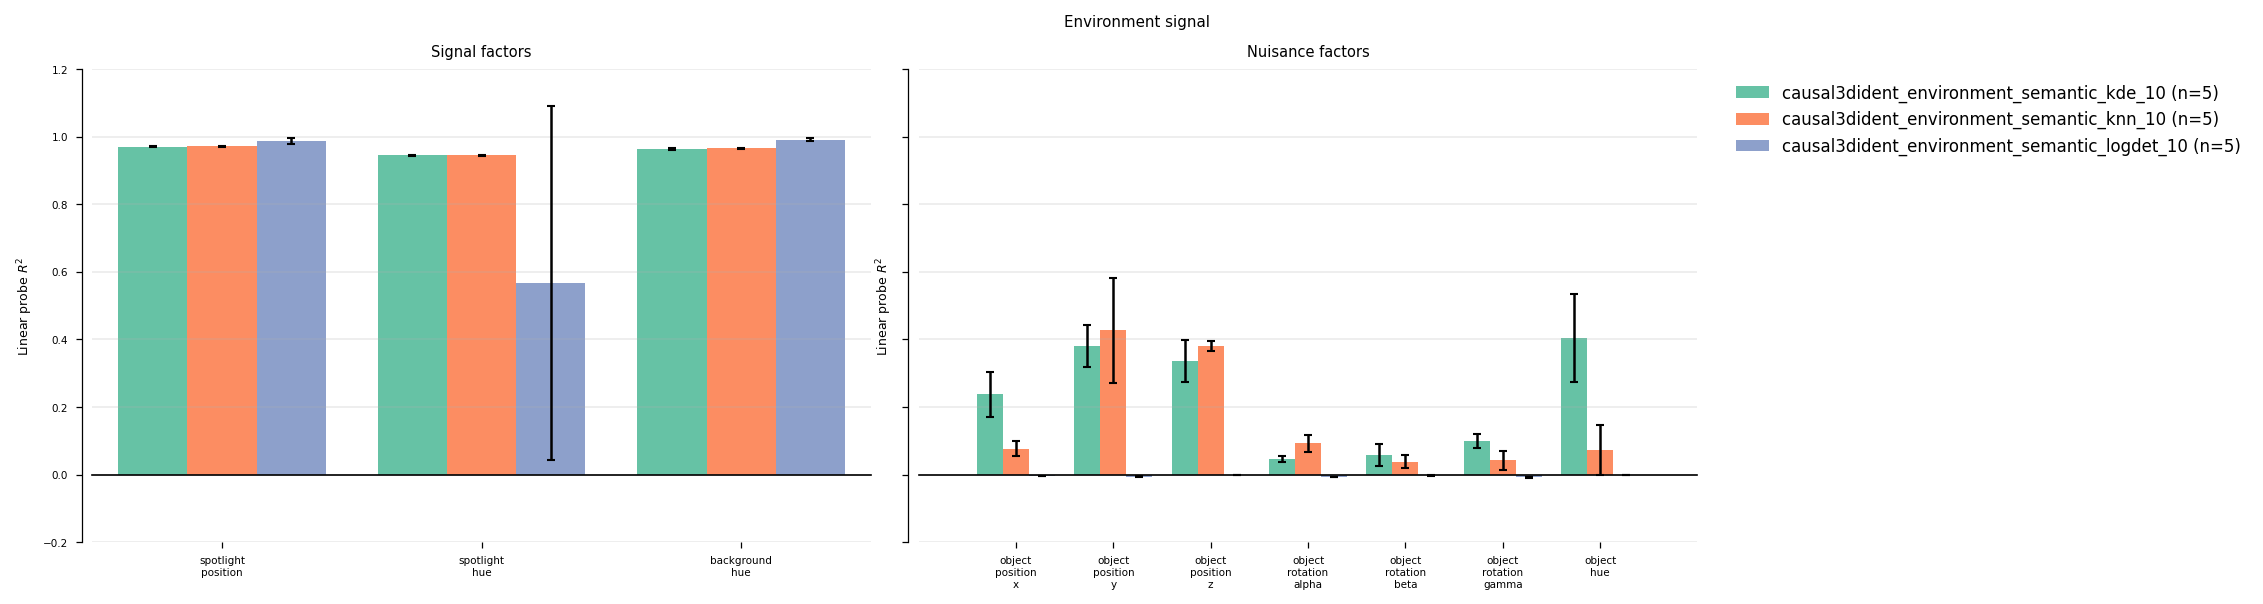

/tmp/ipykernel_2741527/4214246526.py:96: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


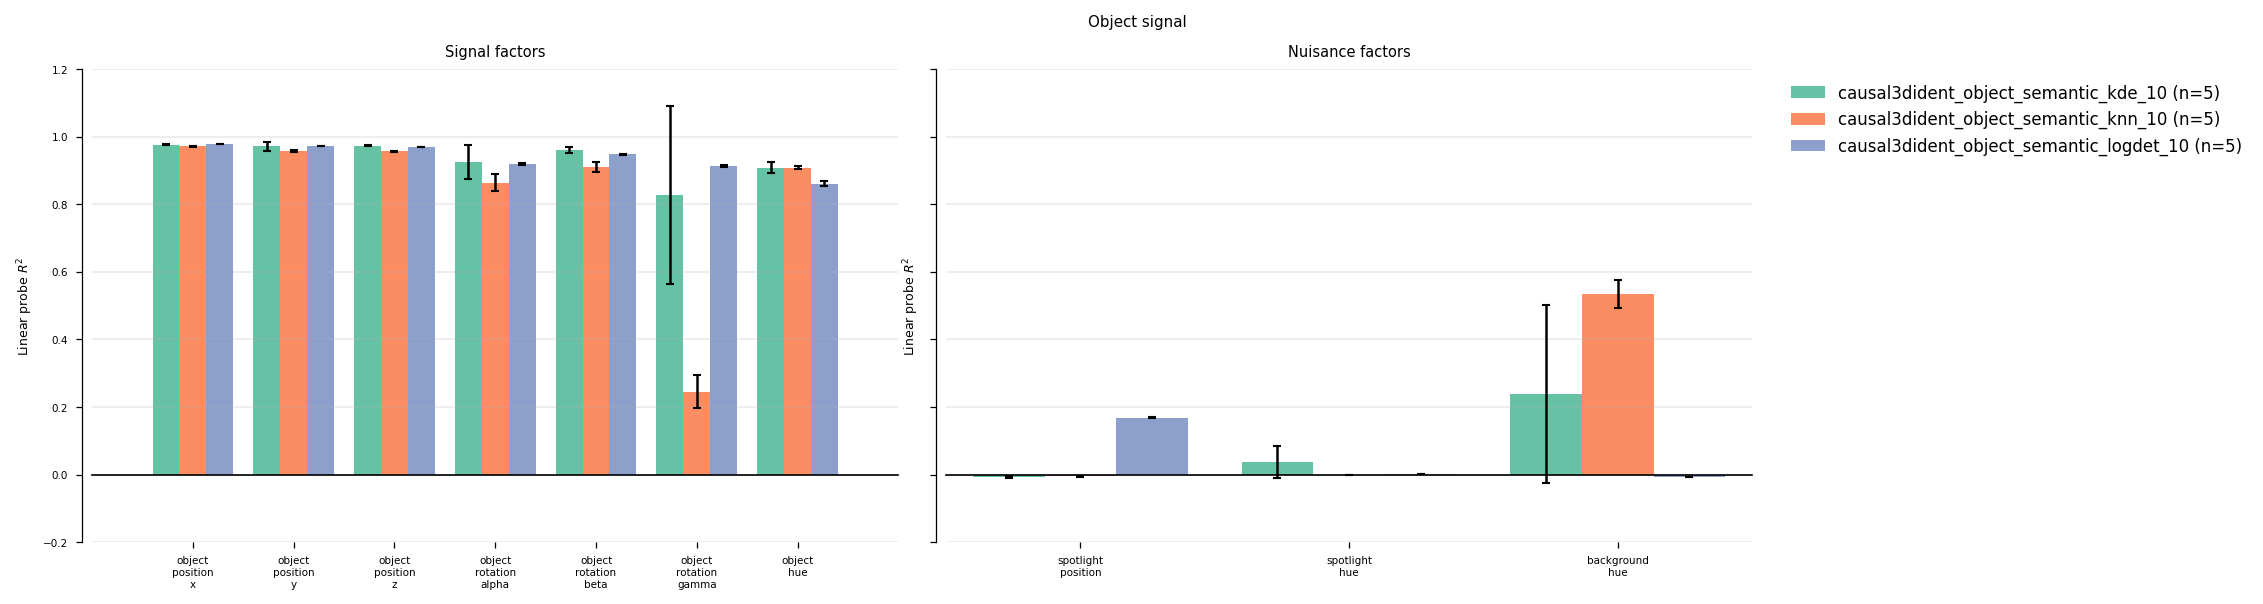

In [29]:
def mean_and_std(values):
    values = np.asarray(values, dtype=float)
    std = values.std(ddof=1) if len(values) > 1 else 0.0
    return values.mean(), std


by_model = defaultdict(list)
for result in results:
    by_model[result['name']].append(result)

summary = []
for model_name, model_results in sorted(by_model.items()):
    signal_affine = mean_and_std([
        result['metrics']['signal_affine_r2'] for result in model_results
    ])
    nuisance_gain = mean_and_std([
        result['metrics']['conditional_nuisance_leakage']['continuous']['mean_incremental_r2']
        for result in model_results
    ])
    class_accuracy = mean_and_std([
        result['metrics']['class']['logistic_accuracy'] for result in model_results
    ])
    gaussian_nll = mean_and_std([
        result['metrics']['gaussian_conditional']['model']['mean_gaussian_nll_per_dimension']
        for result in model_results
    ])
    summary.append({
        'model': model_name,
        'seeds': sorted(result['seed'] for result in model_results),
        'n_seeds': len(model_results),
        'd_z': model_results[0]['state_dim'],
        'equal_dimensional': model_results[0]['metrics']['gaussian_conditional']['metadata']['equal_signal_code_dimensions'],
        'signal_affine_r2_mean': signal_affine[0],
        'signal_affine_r2_std': signal_affine[1],
        'conditional_nuisance_delta_r2_mean': nuisance_gain[0],
        'conditional_nuisance_delta_r2_std': nuisance_gain[1],
        'class_accuracy_mean': class_accuracy[0],
        'class_accuracy_std': class_accuracy[1],
        'gaussian_nll_per_dim_mean': gaussian_nll[0],
        'gaussian_nll_per_dim_std': gaussian_nll[1],
    })
display(summary)

def plot_scenario_r2(signal_indices, scenario):
    scenario_results = [
        result for result in results
        if tuple(result['metrics']['metadata']['signal_indices']) == signal_indices
    ]
    fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
    fig.suptitle(scenario['title'])
    if not scenario_results:
        for axis in axes:
            axis.axis('off')
            axis.text(0.5, 0.5, 'No completed checkpoints found', ha='center', va='center')
        plt.show()
        return

    scenario_by_model = defaultdict(list)
    for result in scenario_results:
        scenario_by_model[result['name']].append(result)

    for axis, role in zip(axes, ('signal', 'nuisance')):
        indices = scenario[role]
        names = [CAUSAL3DIDENT_FACTOR_NAMES[index] for index in indices]
        x = np.arange(len(indices))
        width = 0.8 / len(scenario_by_model)
        for model_index, (model_name, model_results) in enumerate(
            sorted(scenario_by_model.items())
        ):
            seed_values = np.asarray([
                [result['metrics']['factors']['linear_r2'][name] for name in names]
                for result in model_results
            ])
            means = seed_values.mean(axis=0)
            stds = (
                seed_values.std(axis=0, ddof=1)
                if len(model_results) > 1
                else np.zeros(len(names))
            )
            offset = (model_index - (len(scenario_by_model) - 1) / 2) * width
            label = f"{model_name} (n={len(model_results)})"
            axis.bar(
                x + offset,
                means,
                width,
                yerr=stds,
                capsize=2,
                label=label,
            )
        axis.axhline(0, color='black', linewidth=0.8)
        axis.set_xticks(x, [name.replace('_', '\n') for name in names])
        axis.set_title(f'{role.capitalize()} factors')
        axis.set_ylabel(r'Linear probe $R^2$')
        axis.grid(axis='y', alpha=0.25)
    axes[1].legend(bbox_to_anchor=(1.03, 1), loc='upper left', fontsize=8)
    fig.tight_layout()
    plt.show()


for signal_indices, scenario in SCENARIOS.items():
    plot_scenario_r2(signal_indices, scenario)

/tmp/ipykernel_2741527/1901494566.py:108: UserWarning: The figure layout has changed to tight
  fig.tight_layout()
/tmp/ipykernel_2741527/1901494566.py:108: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


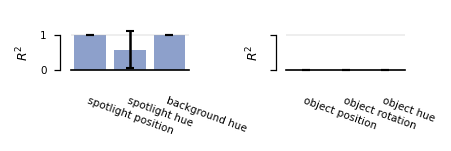

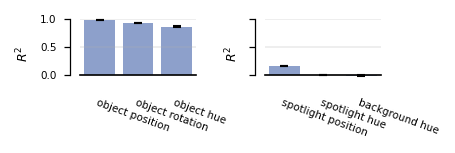

In [30]:
# LINEAR_FACTOR_LABELS = {
#     'object_identity': r'$i_{\mathrm{obj}}$',
#     'object_position_x': r'$p_{\text{obj-}x}$',
#     'object_position_y': r'$p_{\text{obj-}y}$',
#     'object_position_z': r'$p_{\text{obj-}z}$',
#     'object_rotation_alpha': r'$\theta_{\text{obj-}\alpha}$',
#     'object_rotation_beta': r'$\theta_{\text{obj-}\beta}$',
#     'object_rotation_gamma': r'$\theta_{\text{obj-}\gamma}$',
#     'object_hue': r'$h_{\mathrm{obj}}$',
#     'spotlight_position': r'$p_{\mathrm{spot}}$',
#     'spotlight_hue': r'$h_{\mathrm{spot}}$',
#     'background_hue': r'$h_{\mathrm{back}}$',
# }
LINEAR_FACTOR_LABELS = {
    'object_identity': r'object identity',
    'object_position': r'object position',
    'object_rotation': r'object rotation',
    'object_position_x': r'object position x',
    'object_position_y': r'object position y',
    'object_position_z': r'object position z',
    'object_rotation_alpha': r'object rotation $\alpha$',
    'object_rotation_beta': r'object rotation $\beta$',
    'object_rotation_gamma': r'object rotation $\gamma$',
    'object_hue': r'object hue',
    'spotlight_position': r'spotlight position',
    'spotlight_hue': r'spotlight hue',
    'background_hue': r'background hue',
}

LINEAR_FACTOR_GROUPS = (
    ('object_position', (0, 1, 2)),
    ('object_rotation', (3, 4, 5)),
    ('object_hue', (7,)),
    ('spotlight_position', (6,)),
    ('spotlight_hue', (8,)),
    ('background_hue', (9,)),
)


def scenario_group_names(scenario, role):
    role_indices = set(scenario[role])
    return [
        name for name, indices in LINEAR_FACTOR_GROUPS
        if set(indices).issubset(role_indices)
    ]

def plot_logdet_linear_r2(signal_indices, scenario):
    scenario_results = [
        result for result in results
        if result['loss'] == 'logdet'
        and tuple(result['metrics']['metadata']['signal_indices']) == signal_indices
    ]
    panel_sizes = [
        len(scenario_group_names(scenario, role))
        for role in ('signal', 'nuisance')
    ]
    fig, axes = plt.subplots(
        1, 2, figsize=(3, 1), sharey=True,
        gridspec_kw={'width_ratios': panel_sizes},
    )
    if not scenario_results:
        for axis in axes:
            axis.axis('off')
            axis.text(0.5, 0.5, 'No completed logdet checkpoints found', ha='center', va='center')
        plt.show()
        return

    for axis, role in zip(axes, ('signal', 'nuisance')):
        names = scenario_group_names(scenario, role)
        seed_values = np.asarray([
            [
                result['metrics']['factors']['groups'][name]['linear_r2']
                for name in names
            ]
            for result in scenario_results
        ])
        means = seed_values.mean(axis=0)
        stds = (
            seed_values.std(axis=0, ddof=1)
            if len(scenario_results) > 1 else np.zeros(len(names))
        )
        x = np.arange(len(names))
        axis.bar(
            x, means, 0.8, yerr=stds, capsize=2, color=CAT_COLORS[2],
            label=f"logdet (n={len(scenario_results)})",
        )
        axis.axhline(0, color='black', linewidth=0.8)
        axis.set_xlim(-0.5, len(names) - 0.5)
        axis.set_xticks(x)
        axis.set_xticklabels([])
        axis.tick_params(axis='x', length=0)
        for xi, name in zip(x, names):
            axis.annotate(
                LINEAR_FACTOR_LABELS[name],
                xy=(xi, 0),
                xycoords=('data', 'axes fraction'),
                xytext=(-2, -4),
                textcoords='offset points',
                rotation=-20,
                ha='left',
                va='top',
                fontsize=5,
                annotation_clip=False,
            )
        # axis.set_title(f'{role.capitalize()} factors')
        axis.set_ylabel(r'$R^2$')
        axis.grid(axis='y', alpha=0.25)
    fig.tight_layout()
    plt.savefig(f"plots/c3d_logdet{scenario['title']}.pdf")


for signal_indices, scenario in SCENARIOS.items():
    plot_logdet_linear_r2(signal_indices, scenario)

## Print a LaTeX table of the R² metrics

Each row is one scenario and loss, with runs across seeds aggregated as mean $\pm$ sample standard deviation. Factor headers use $p$ for object position, $r$ for object rotation, and $h$ for hue; subscripts $o$, $s$, and $b$ denote object, spotlight, and background. Light-gray cells are semantic quantities (signal factors and `signal_affine`), and means above $0.8$ are bold. Requires LaTeX packages `booktabs`, `graphicx`, and `xcolor` with the `table` option. `Conditional nuisance gain` is the incremental linear $R^2$ of predicting nuisance from $[S,Z]$ over predicting it from $S$ alone, so values near zero are desirable.

In [31]:
def latex_escape(value):
    return str(value).replace('\\', r'\textbackslash{}').replace('_', r'\_').replace('&', r'\&')


def format_aggregate(values, semantic=False, bold_threshold=0.9):
    values = np.asarray(values, dtype=float)
    mean = values.mean()
    std = values.std(ddof=1) if len(values) > 1 else 0.0
    formatted = rf'{mean:.2f}\,\scalebox{{0.7}}{{$\pm {std:.2f}$}}'
    # formatted = rf'{mean:.2f}'
    if mean > bold_threshold:
        formatted = f'\\mathbf{{{formatted}}}'
    cell = f'${formatted}$'
    return f'\\cellcolor{{gray!15}} {cell}' if semantic else cell


by_scenario_model = defaultdict(list)
for result in results:
    signal_indices = tuple(result['metrics']['metadata']['signal_indices'])
    by_scenario_model[(signal_indices, result['loss'])].append(result)

table_factor_names = (
    *CAUSAL3DIDENT_FACTOR_NAMES[:6],
    'object_hue',
    'spotlight_position',
    'spotlight_hue',
    'background_hue',
)
factor_indices = {name: index for index, name in enumerate(CAUSAL3DIDENT_FACTOR_NAMES)}
factor_labels = {
    'object_position_x': r'$p_{\text{obj-}x}$',
    'object_position_y': r'$p_{\text{obj-}y}$',
    'object_position_z': r'$p_{\text{obj-}z}$',
    'object_rotation_alpha': r'$\theta_{\text{obj-}\alpha}$',
    'object_rotation_beta': r'$\theta_{\text{obj-}\beta}$',
    'object_rotation_gamma': r'$\theta_{\text{obj-}\gamma}$',
    'object_hue': r'$h_\text{obj}$',
    'spotlight_position': r'$p_\text{spot}$',
    'spotlight_hue': r'$h_\text{spot}$',
    'background_hue': r'$h_\text{back}$',
}
rows = []
for (signal_indices, model_name), model_results in sorted(
    by_scenario_model.items(),
    key=lambda item: (SCENARIOS.get(item[0][0], {}).get('title', str(item[0][0])), item[0][1]),
):
    scenario = SCENARIOS.get(signal_indices)
    scenario_name = scenario['title'] if scenario else str(signal_indices)
    cells = []
    for factor_name in table_factor_names:
        values = [result['metrics']['factors']['linear_r2'][factor_name] for result in model_results]
        cells.append(format_aggregate(values, semantic=factor_indices[factor_name] in signal_indices))
    # signal_affine = [result['metrics']['signal_affine_r2'] for result in model_results]
    # cells.append(format_aggregate(signal_affine, semantic=True))
    # nuisance_gain = [
    #     result['metrics']['conditional_nuisance_leakage']['continuous']['mean_incremental_r2']
    #     for result in model_results
    # ]
    # cells.append(format_aggregate(nuisance_gain))
    rows.append((scenario_name, model_name, cells))

linebreak = chr(92) * 2
print(r'\begin{tabular}{ll' + 'c' * len(table_factor_names) + '}')
print(r'\toprule')
headers = [
    'Scenario',
    'Entr. est.',
    *[factor_labels[name] for name in table_factor_names],
    # latex_escape('signal_affine'),
    # latex_escape('conditional_nuisance_gain'),
]
print(' & '.join(headers) + f' {linebreak}')
print(r'\midrule')
previous_scenario = None
for scenario_name, model_name, cells in rows:
    if previous_scenario is not None and scenario_name != previous_scenario:
        print(r'\midrule')
    values = [latex_escape(scenario_name), latex_escape(model_name), *cells]
    print(' & '.join(values) + f' {linebreak}')
    previous_scenario = scenario_name
print(r'\bottomrule')
print(r'\end{tabular}')

\begin{tabular}{llcccccccccc}
\toprule
Scenario & Entr. est. & $p_{\text{obj-}x}$ & $p_{\text{obj-}y}$ & $p_{\text{obj-}z}$ & $\theta_{\text{obj-}\alpha}$ & $\theta_{\text{obj-}\beta}$ & $\theta_{\text{obj-}\gamma}$ & $h_\text{obj}$ & $p_\text{spot}$ & $h_\text{spot}$ & $h_\text{back}$ \\
\midrule
Environment signal & kde & $0.24\,\scalebox{0.7}{$\pm 0.07$}$ & $0.38\,\scalebox{0.7}{$\pm 0.06$}$ & $0.34\,\scalebox{0.7}{$\pm 0.06$}$ & $0.05\,\scalebox{0.7}{$\pm 0.01$}$ & $0.06\,\scalebox{0.7}{$\pm 0.03$}$ & $0.10\,\scalebox{0.7}{$\pm 0.02$}$ & $0.40\,\scalebox{0.7}{$\pm 0.13$}$ & \cellcolor{gray!15} $\mathbf{0.97\,\scalebox{0.7}{$\pm 0.00$}}$ & \cellcolor{gray!15} $\mathbf{0.95\,\scalebox{0.7}{$\pm 0.00$}}$ & \cellcolor{gray!15} $\mathbf{0.96\,\scalebox{0.7}{$\pm 0.00$}}$ \\
Environment signal & knn & $0.08\,\scalebox{0.7}{$\pm 0.02$}$ & $0.43\,\scalebox{0.7}{$\pm 0.16$}$ & $0.38\,\scalebox{0.7}{$\pm 0.01$}$ & $0.09\,\scalebox{0.7}{$\pm 0.03$}$ & $0.04\,\scalebox{0.7}{$\pm 0.02$}$ & $0.0

## Nonlinear recovery with post-hoc MLP decoders

For every checkpoint, a post-hoc multi-output MLP is fitted on representations and all ten continuous factors from the official Causal3DIdent training split. The same fitted decoder is then scored on both its training subset and an independently sampled subset of the official test split. This gives nonlinear $R^2$ for both signal and nuisance factors without using test labels for fitting.

In [32]:
from sklearn.metrics import r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Subset


def collect_official_split(model, cfg, split, maximum):
    dataset = Causal3DIdent(cfg, split=split)
    count = min(maximum, len(dataset))
    split_seed = RANDOM_SEED + (0 if split == 'train' else 1)
    indices = np.random.default_rng(split_seed).choice(len(dataset), count, replace=False)
    z, factors, _, _ = _collect_representations(
        model,
        Subset(dataset, indices),
        representation_key='inferences',
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        device=DEVICE,
        maximum=None,
        sequence_index=0,
        collect_transitions=False,
    )
    return z, factors


def fit_and_score_mlp(train_z, train_factors, test_z, test_factors):
    z_scaler = StandardScaler().fit(train_z)
    factor_scaler = StandardScaler().fit(train_factors)
    scaled_train_z = z_scaler.transform(train_z)
    scaled_test_z = z_scaler.transform(test_z)
    scaled_train_factors = factor_scaler.transform(train_factors)
    scaled_test_factors = factor_scaler.transform(test_factors)
    decoder = MLPRegressor(
        hidden_layer_sizes=MLP_HIDDEN_LAYER_SIZES,
        batch_size=min(256, len(train_z)),
        max_iter=MLP_MAX_ITER,
        early_stopping=True,
        n_iter_no_change=20,
        random_state=RANDOM_SEED,
    ).fit(scaled_train_z, scaled_train_factors)
    split_scores = {}
    for split, z, factors in (
        ('train', scaled_train_z, scaled_train_factors),
        ('test', scaled_test_z, scaled_test_factors),
    ):
        values = np.atleast_1d(
            r2_score(factors, decoder.predict(z), multioutput='raw_values')
        )
        split_scores[split] = {
            'per_factor_r2': {
                name: float(value)
                for name, value in zip(CAUSAL3DIDENT_FACTOR_NAMES, values, strict=True)
            },
        }
    split_scores['metadata'] = {
        'n_train': len(train_z),
        'n_test': len(test_z),
        'hidden_layer_sizes': MLP_HIDDEN_LAYER_SIZES,
        'iterations': decoder.n_iter_,
    }
    return split_scores


mlp_results = []
mlp_failures = []
for run_number, run in enumerate(runs, 1):
    print(f"[{run_number}/{len(runs)}] {run['name']} seed={run['seed']}")
    try:
        cfg = _load_config(run['config'])
        cfg.data.settings.root = str(DATA_ROOT)
        cfg.data.settings.stochastic_transitions = False
        model = _load_local_model(run['checkpoint'], cfg, DEVICE)
        train_z, train_factors = collect_official_split(
            model, cfg, 'train', MAX_PROBE_TRAIN,
        )
        test_z, test_factors = collect_official_split(
            model, cfg, 'test', MAX_PROBE_TEST,
        )
        mlp_metrics = fit_and_score_mlp(
            train_z, train_factors, test_z, test_factors,
        )
        signal_indices = tuple(int(index) for index in cfg.data.settings.signal_indices)
        mlp_results.append({**run, 'signal_indices': signal_indices, 'mlp_metrics': mlp_metrics})
    except Exception as error:
        mlp_failures.append({
            'name': run['name'], 'seed': run['seed'], 'error': repr(error),
        })
        print('  FAILED:', repr(error))
    finally:
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

if mlp_failures:
    print('Post-hoc MLP failures:')
    display(mlp_failures)
if not mlp_results:
    raise RuntimeError('No post-hoc MLP decoder was evaluated successfully')
print(f'Successfully evaluated post-hoc MLP decoders for {len(mlp_results)} runs.')

[1/30] causal3dident_environment_semantic_kde_10 seed=1
[2/30] causal3dident_environment_semantic_kde_10 seed=2
[3/30] causal3dident_environment_semantic_kde_10 seed=3
[4/30] causal3dident_environment_semantic_kde_10 seed=4
[5/30] causal3dident_environment_semantic_kde_10 seed=5
[6/30] causal3dident_environment_semantic_knn_10 seed=1
[7/30] causal3dident_environment_semantic_knn_10 seed=2
[8/30] causal3dident_environment_semantic_knn_10 seed=3
[9/30] causal3dident_environment_semantic_knn_10 seed=4
[10/30] causal3dident_environment_semantic_knn_10 seed=5
[11/30] causal3dident_environment_semantic_logdet_10 seed=1
[12/30] causal3dident_environment_semantic_logdet_10 seed=2
[13/30] causal3dident_environment_semantic_logdet_10 seed=3
[14/30] causal3dident_environment_semantic_logdet_10 seed=4
[15/30] causal3dident_environment_semantic_logdet_10 seed=5
[16/30] causal3dident_object_semantic_kde_10 seed=1
[17/30] causal3dident_object_semantic_kde_10 seed=2
[18/30] causal3dident_object_semant

### Train and test nonlinear $R^2$ plots

These mirror the linear-probe figures: every figure separates signal and nuisance factors. A separate figure is shown for each official dataset split. Bars show the mean across seeds and error bars show the sample standard deviation.

/tmp/ipykernel_2741527/3066687969.py:47: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


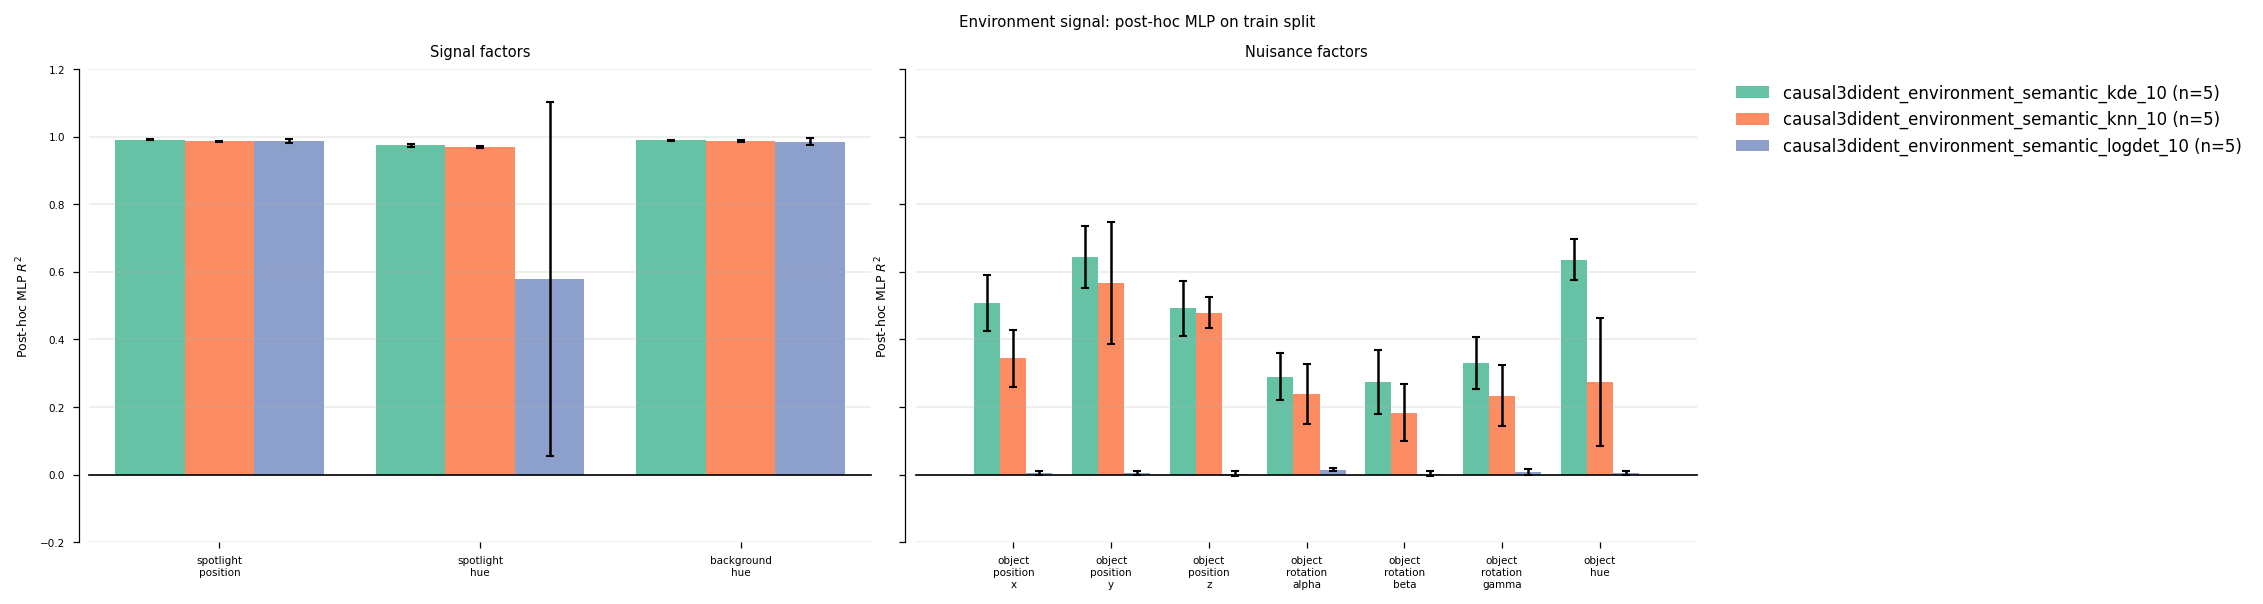

/tmp/ipykernel_2741527/3066687969.py:47: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


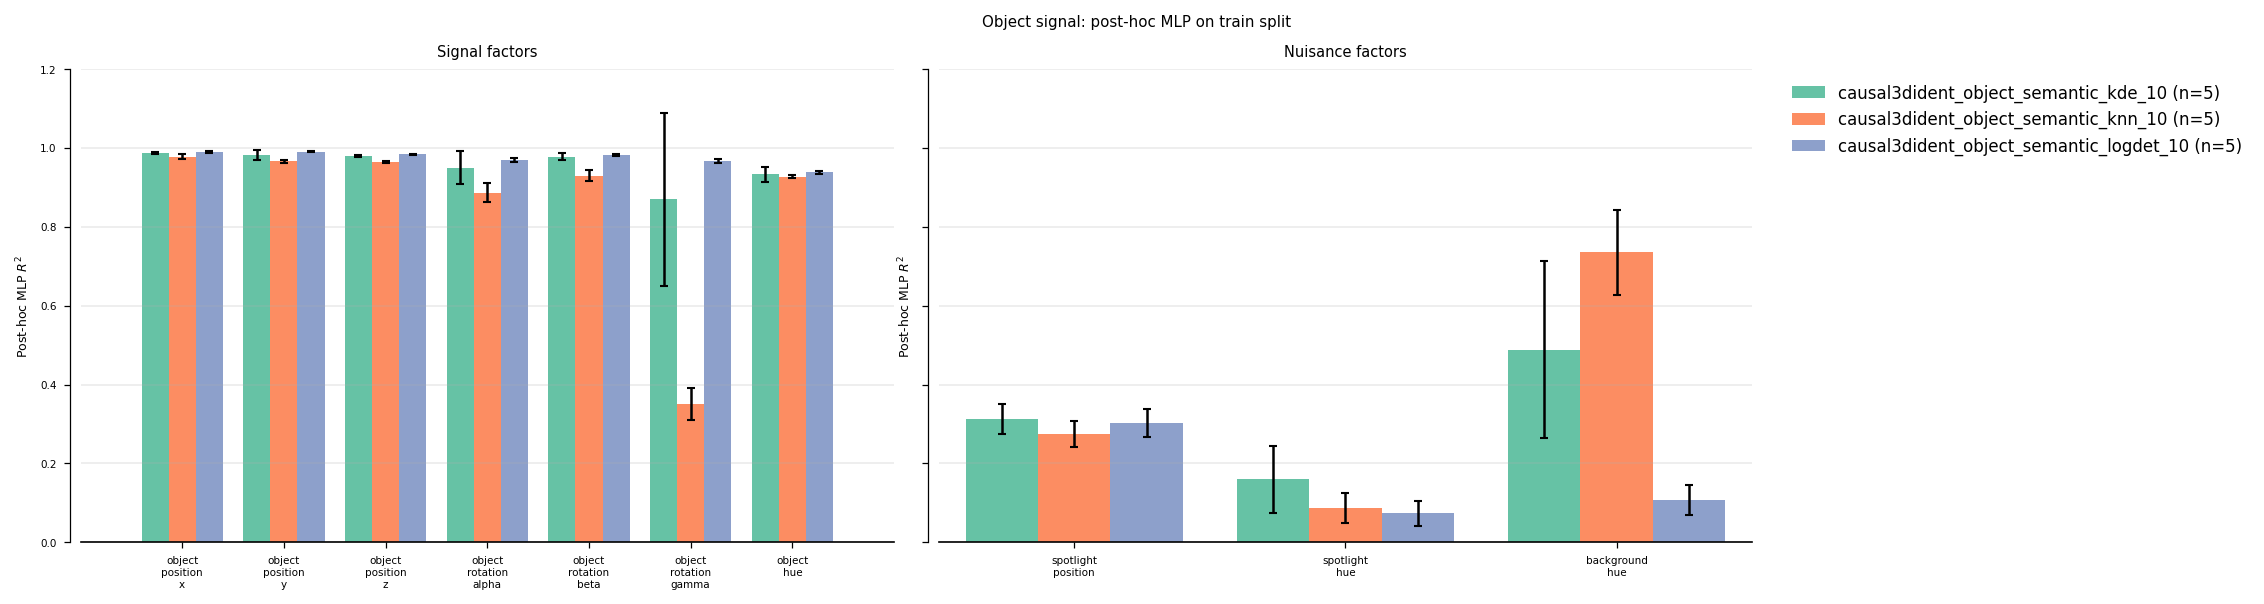

/tmp/ipykernel_2741527/3066687969.py:47: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


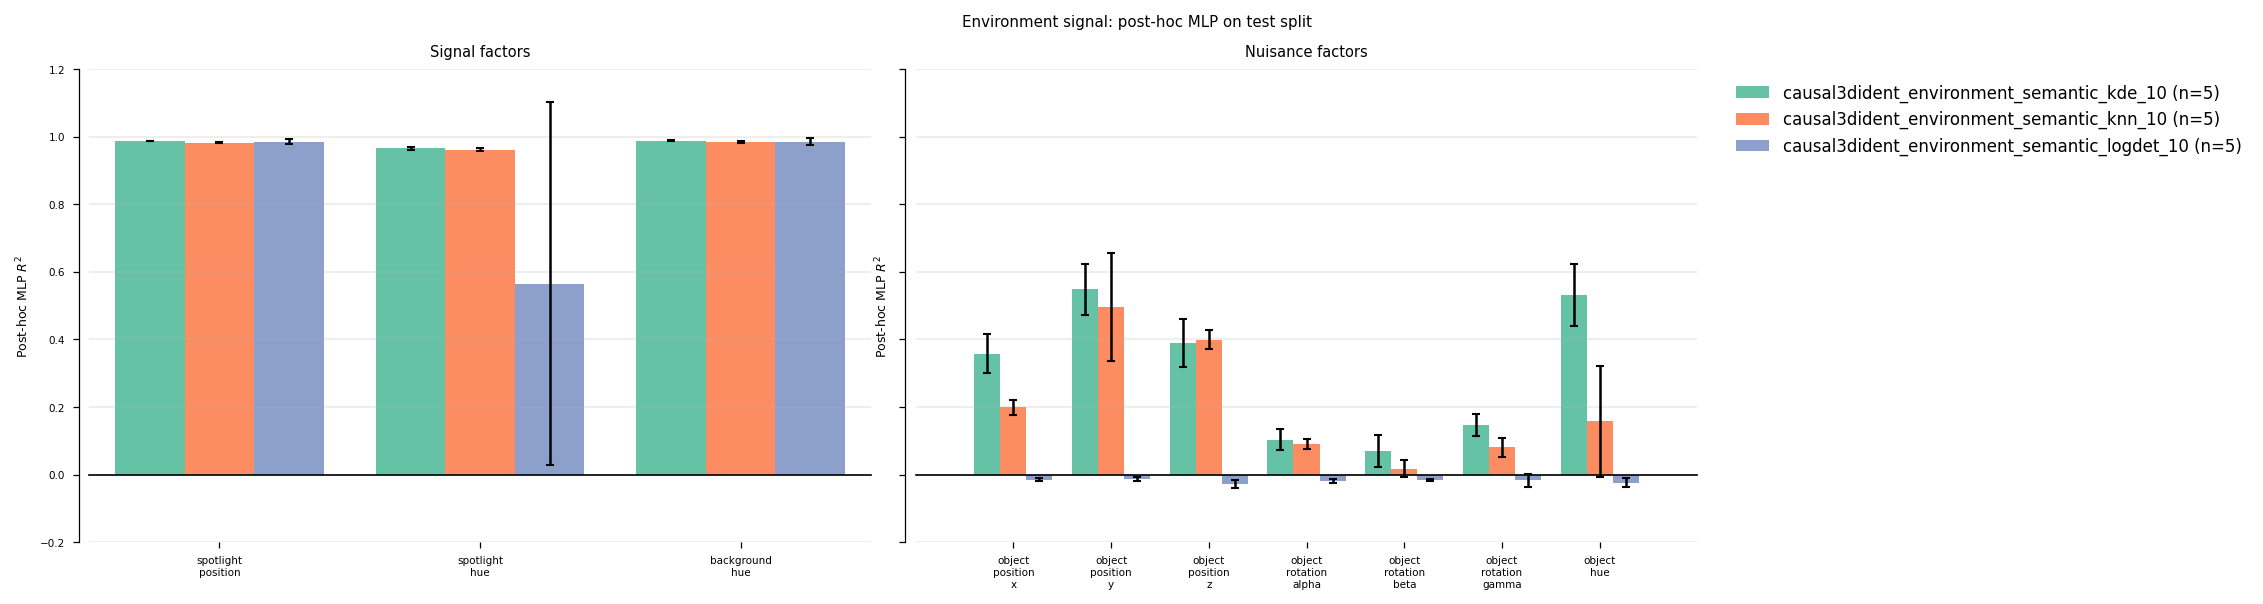

/tmp/ipykernel_2741527/3066687969.py:47: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


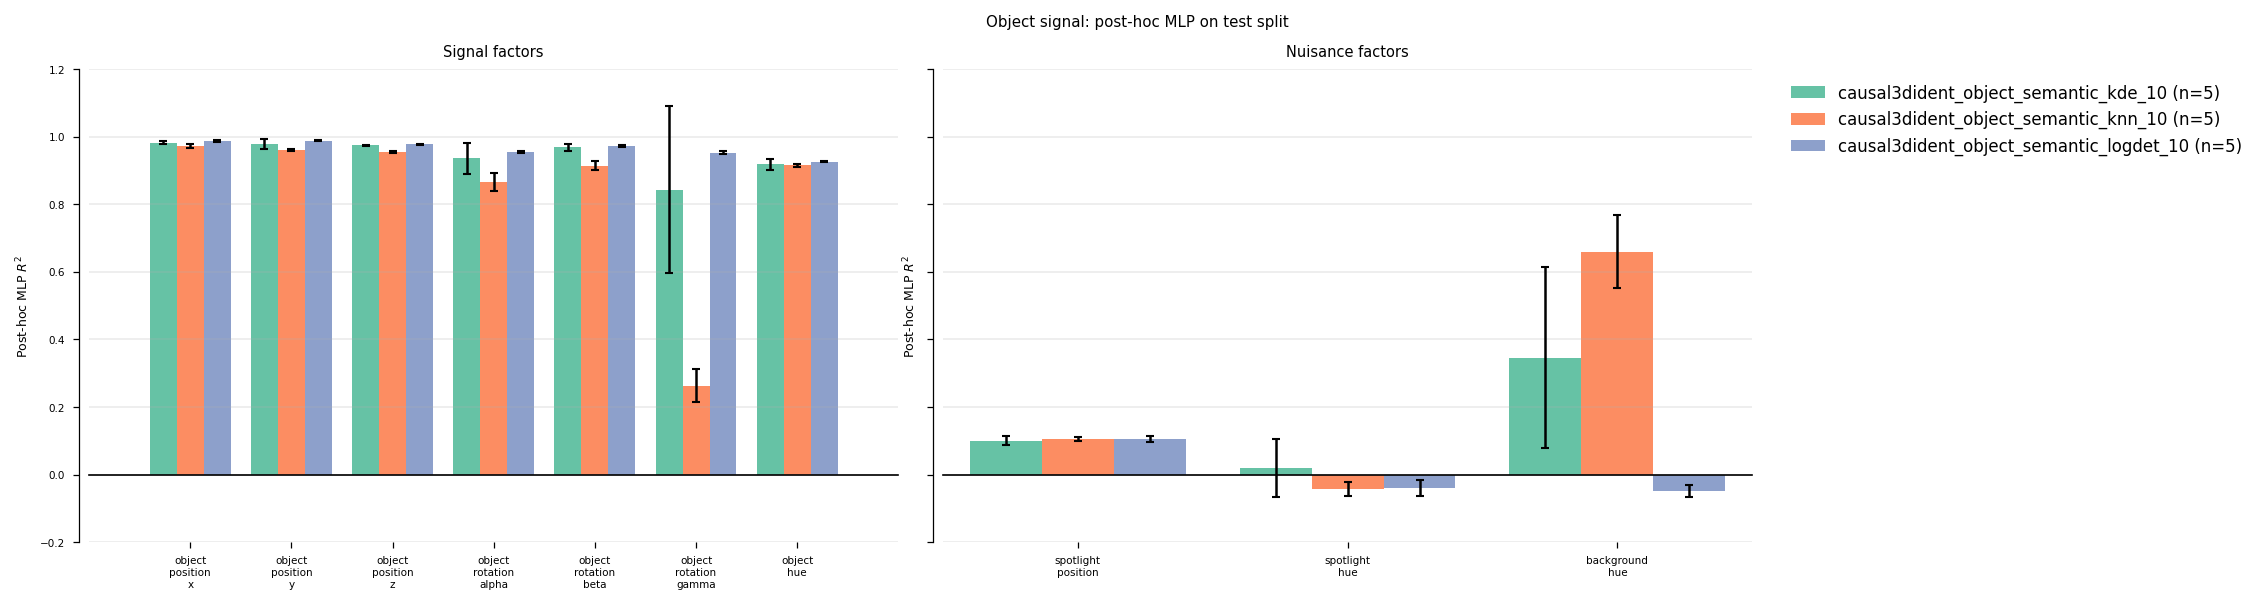

In [33]:
def plot_scenario_mlp_r2(signal_indices, scenario, split):
    scenario_results = [
        result for result in mlp_results
        if result['signal_indices'] == signal_indices
    ]
    fig, axes = plt.subplots(1, 2, figsize=(15, 4), sharey=True)
    fig.suptitle(f"{scenario['title']}: post-hoc MLP on {split} split")
    if not scenario_results:
        for axis in axes:
            axis.axis('off')
            axis.text(0.5, 0.5, 'No completed checkpoints found', ha='center', va='center')
        plt.show()
        return

    scenario_by_model = defaultdict(list)
    for result in scenario_results:
        scenario_by_model[result['name']].append(result)

    for axis, role in zip(axes, ('signal', 'nuisance')):
        indices = scenario[role]
        names = [CAUSAL3DIDENT_FACTOR_NAMES[index] for index in indices]
        x = np.arange(len(indices))
        width = 0.8 / len(scenario_by_model)
        for model_index, (model_name, model_results) in enumerate(
            sorted(scenario_by_model.items())
        ):
            seed_values = np.asarray([
                [result['mlp_metrics'][split]['per_factor_r2'][name] for name in names]
                for result in model_results
            ])
            means = seed_values.mean(axis=0)
            stds = (
                seed_values.std(axis=0, ddof=1)
                if len(model_results) > 1 else np.zeros(len(names))
            )
            offset = (model_index - (len(scenario_by_model) - 1) / 2) * width
            axis.bar(
                x + offset, means, width, yerr=stds, capsize=2,
                label=f"{model_name} (n={len(model_results)})",
            )
        axis.axhline(0, color='black', linewidth=0.8)
        axis.set_xticks(x, [name.replace('_', '\n') for name in names])
        axis.set_title(f'{role.capitalize()} factors')
        axis.set_ylabel(r'Post-hoc MLP $R^2$')
        axis.grid(axis='y', alpha=0.25)
    axes[1].legend(bbox_to_anchor=(1.03, 1), loc='upper left', fontsize=8)
    fig.tight_layout()
    plt.show()


for split in ('train', 'test'):
    for signal_indices, scenario in SCENARIOS.items():
        plot_scenario_mlp_r2(signal_indices, scenario, split)

### LaTeX table of post-hoc MLP $R^2$

The table has the same factor columns and semantic-cell shading as the linear table. Each post-hoc MLP is fitted once on the official training split; its train and test scores are shown in separate rows.

In [34]:
by_mlp_scenario_loss = defaultdict(list)
for result in mlp_results:
    by_mlp_scenario_loss[(result['signal_indices'], result['loss'])].append(result)

mlp_rows = []
for (signal_indices, loss), model_results in sorted(
    by_mlp_scenario_loss.items(),
    key=lambda item: (SCENARIOS.get(item[0][0], {}).get('title', str(item[0][0])), item[0][1]),
):
    scenario = SCENARIOS.get(signal_indices)
    scenario_name = scenario['title'] if scenario else str(signal_indices)
    for split in ('train', 'test'):
        cells = []
        for factor_name in table_factor_names:
            values = [
                result['mlp_metrics'][split]['per_factor_r2'][factor_name]
                for result in model_results
            ]
            cells.append(format_aggregate(
                values, semantic=factor_indices[factor_name] in signal_indices,
            ))
        mlp_rows.append((scenario_name, loss, split, cells))

print(r'\begin{tabular}{lll' + 'c' * len(table_factor_names) + '}')
print(r'\toprule')
headers = ['Scenario', 'Entr. est.', 'Split', *[factor_labels[name] for name in table_factor_names]]
print(' & '.join(headers) + f' {linebreak}')
print(r'\midrule')
previous_scenario = None
for scenario_name, loss, split, cells in mlp_rows:
    if previous_scenario is not None and scenario_name != previous_scenario:
        print(r'\midrule')
    values = [latex_escape(scenario_name), latex_escape(loss), latex_escape(split), *cells]
    print(' & '.join(values) + f' {linebreak}')
    previous_scenario = scenario_name
print(r'\bottomrule')
print(r'\end{tabular}')

\begin{tabular}{lllcccccccccc}
\toprule
Scenario & Entr. est. & Split & $p_{\text{obj-}x}$ & $p_{\text{obj-}y}$ & $p_{\text{obj-}z}$ & $\theta_{\text{obj-}\alpha}$ & $\theta_{\text{obj-}\beta}$ & $\theta_{\text{obj-}\gamma}$ & $h_\text{obj}$ & $p_\text{spot}$ & $h_\text{spot}$ & $h_\text{back}$ \\
\midrule
Environment signal & kde & train & $0.51\,\scalebox{0.7}{$\pm 0.08$}$ & $0.64\,\scalebox{0.7}{$\pm 0.09$}$ & $0.49\,\scalebox{0.7}{$\pm 0.08$}$ & $0.29\,\scalebox{0.7}{$\pm 0.07$}$ & $0.27\,\scalebox{0.7}{$\pm 0.10$}$ & $0.33\,\scalebox{0.7}{$\pm 0.08$}$ & $0.64\,\scalebox{0.7}{$\pm 0.06$}$ & \cellcolor{gray!15} $\mathbf{0.99\,\scalebox{0.7}{$\pm 0.00$}}$ & \cellcolor{gray!15} $\mathbf{0.97\,\scalebox{0.7}{$\pm 0.00$}}$ & \cellcolor{gray!15} $\mathbf{0.99\,\scalebox{0.7}{$\pm 0.00$}}$ \\
Environment signal & kde & test & $0.36\,\scalebox{0.7}{$\pm 0.06$}$ & $0.55\,\scalebox{0.7}{$\pm 0.08$}$ & $0.39\,\scalebox{0.7}{$\pm 0.07$}$ & $0.10\,\scalebox{0.7}{$\pm 0.03$}$ & $0.07\,\scalebox{